# NIKHIL TEST: EVAL MODEL

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np 
import torch 
import matplotlib.pyplot as plt 

from torch.utils.data import DataLoader
from neuralop.models import FNO
from neuralop.data.datasets.tensor_dataset import TensorDataset

import sys 
sys.path.append("/home/jingpei/Documents/arclab/neuraloperator/safe_neural_operators")
# Import dataset and data collection related functions
from hjr_dataset import HJRDataset
from data_collection import get_dynamics_model_given_disturbance_fn, get_disturbance_function_sincos

# Append path to quad2d environments and associated files
sys.path.append("/home/jingpei/Documents/arclab/L4DC25_project/custom_sim/quad2d")
sys.path.append("/home/jingpei/Documents/arclab/L4DC25_project/custom_sim")
sys.path.append("/home/jingpei/Documents/arclab/L4DC25_project")

# Deepreach Imports 
from deepreach.dynamics import dynamics
from deepreach.utils.comparisons import GroundTruthHJSolution


In [2]:
# Load the model 
model_dir = "/media/jingpei/DATA/fno_models/safe_neural-7-16-25_500data"
dataset_path = "/media/jingpei/DATA/fno_gp_data_2000"
device = "cuda:0" if torch.cuda.is_available() else "cpu"

model = FNO.from_checkpoint(save_folder=model_dir, save_name="model")
model = model.to(device)

In [3]:
# Load dataset - just to create the data processor 
# Dataset Parameters 
data_root_dir = dataset_path 
samples_for_train = 50#400 #500
samples_for_test = 50 
datapoints_per_sample = 1000
batch_size = 256 #32
pre_sample_dataset = True 
encode_output = False 
encode_input = True 
encoding = "channel-wise"
full_ordered_dataset = False

dataset = HJRDataset(root_dir=data_root_dir, 
                    samples_for_train=samples_for_train, 
                    samples_for_test=samples_for_test, 
                    datapoints_per_sample=datapoints_per_sample,

                    batch_size=batch_size, 
                    pre_sample_dataset=pre_sample_dataset, 

                    encode_output=encode_output,
                    encode_input=encode_input,
                    encoding=encoding, 
                    full_ordered_dataset=full_ordered_dataset)

data_processor = dataset.data_processor

/home/jingpei/Documents/arclab/neuraloperator/safe_neural_operators/data_collection.py:115: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  grid_states = torch.load(grid_state

In [4]:
# seed
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

In [5]:
# Get Input and Ground Truth Data
eval_num = 25 

eval_dataset = dataset.test_dbs[0]
data_loader = DataLoader(eval_dataset, 
                         batch_size=1, 
                         shuffle=False, 
                         num_workers=1, 
                         pin_memory=True, 
                         persistent_workers=False)

for i, eval_index in enumerate(data_loader): 
    if i == eval_num: 
        print(i)
        data = eval_dataset[i]
        processed_data = data_processor.preprocess(data, batched=False)

        x = processed_data['x'].to(device)
        y = processed_data['y'].to(device).unsqueeze(0)
        y_pred = model.forward(x)
        break 

gt_value_function_samplenum = eval_dataset.sample_tuple_list[eval_num][2]
print(eval_dataset.sample_tuple_list[eval_num])
gt_value_function = eval_dataset.output_data[gt_value_function_samplenum]
gt_input = eval_dataset.input_data[gt_value_function_samplenum]
gt_sample_tuple = data["sample_tuple"]

print("sample tuple og: ", data["sample_tuple"])

25
[27 34 46]
sample tuple og:  [[27 34 46]]


In [6]:
thing = data['x'][0]
print("Input shape: ", thing.shape)
print(thing[1, :, :])
print(thing[2, :, :])

xvels = eval_dataset.grid_states[0, 0, :, 0, 2]
yvels = eval_dataset.grid_states[0, 0, 0, :, 3]

xvel_slice_found = np.argmin(np.abs(xvels - thing[1, 0, 0].detach().cpu().numpy()))
yvel_slice_found = np.argmin(np.abs(yvels - thing[2, 0, 0].detach().cpu().numpy()))

xvel_slice_sampletuple = eval_dataset.sample_tuple_list[eval_num][0]
yvel_slice_sampletuple = eval_dataset.sample_tuple_list[eval_num][1]

print("xvel_slice: ", xvel_slice_found)
print("yvel_slice: ", yvel_slice_found)
print("sample tuple verification: ", eval_dataset.sample_tuple_list[eval_num])

print("xvel found: ", xvels[xvel_slice_found])
print("yvel found: ", yvels[yvel_slice_found])
print("xvel tuple: ", xvels[xvel_slice_sampletuple])
print("yvel tuple: ", yvels[yvel_slice_sampletuple])

Input shape:  torch.Size([3, 41, 41])
tensor([[0.5887, 0.5887, 0.5887,  ..., 0.5887, 0.5887, 0.5887],
        [0.5887, 0.5887, 0.5887,  ..., 0.5887, 0.5887, 0.5887],
        [0.5887, 0.5887, 0.5887,  ..., 0.5887, 0.5887, 0.5887],
        ...,
        [0.5887, 0.5887, 0.5887,  ..., 0.5887, 0.5887, 0.5887],
        [0.5887, 0.5887, 0.5887,  ..., 0.5887, 0.5887, 0.5887],
        [0.5887, 0.5887, 0.5887,  ..., 0.5887, 0.5887, 0.5887]])
tensor([[1.1795, 1.1795, 1.1795,  ..., 1.1795, 1.1795, 1.1795],
        [1.1795, 1.1795, 1.1795,  ..., 1.1795, 1.1795, 1.1795],
        [1.1795, 1.1795, 1.1795,  ..., 1.1795, 1.1795, 1.1795],
        ...,
        [1.1795, 1.1795, 1.1795,  ..., 1.1795, 1.1795, 1.1795],
        [1.1795, 1.1795, 1.1795,  ..., 1.1795, 1.1795, 1.1795],
        [1.1795, 1.1795, 1.1795,  ..., 1.1795, 1.1795, 1.1795]])
xvel_slice:  26
yvel_slice:  32
sample tuple verification:  [27 34 46]
xvel found:  0.60000014
yvel found:  1.2
xvel tuple:  0.70000005
yvel tuple:  1.4000001


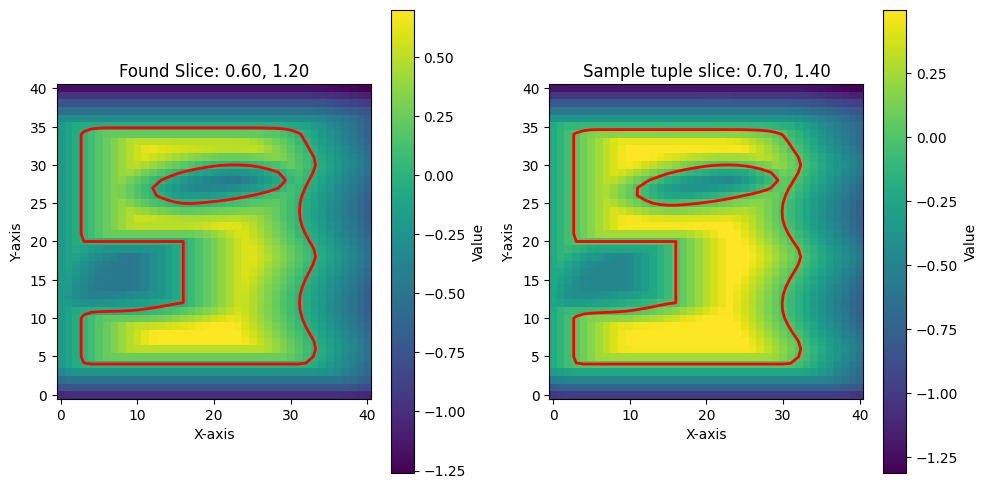

In [7]:
# Plot the found slices
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot y
axes[0].imshow(gt_value_function[0, :, :, :, :][:, :, xvel_slice_found, yvel_slice_found].cpu().detach().numpy(), cmap='viridis', origin='lower')
axes[0].contour(gt_value_function[0, :, :, :, :][:, :, xvel_slice_found, yvel_slice_found].cpu().detach().numpy(), levels=[0], colors="red", linewidths=2)
axes[0].set_title(f"Found Slice: {xvels[xvel_slice_found]:.2f}, {yvels[yvel_slice_found]:.2f}")
axes[0].set_xlabel("X-axis")
axes[0].set_ylabel("Y-axis")
cbar = fig.colorbar(axes[0].images[0], ax=axes[0])
cbar.set_label("Value")

# Plot y_pred
axes[1].imshow(gt_value_function[0, :, :, :, :][:, :, xvel_slice_sampletuple, yvel_slice_sampletuple].cpu().detach().numpy(), cmap='viridis', origin='lower')
axes[1].contour(gt_value_function[0, :, :, :, :][:, :, xvel_slice_sampletuple, yvel_slice_sampletuple].cpu().detach().numpy(), levels=[0], colors="red", linewidths=2)
axes[1].set_title(f"Sample tuple slice: {xvels[xvel_slice_sampletuple]:.2f}, {yvels[yvel_slice_sampletuple]:.2f}")
axes[1].set_xlabel("X-axis")
axes[1].set_ylabel("Y-axis")
cbar = fig.colorbar(axes[1].images[0], ax=axes[1])
cbar.set_label("Value")

plt.tight_layout()
plt.show()

max difference:  0.0


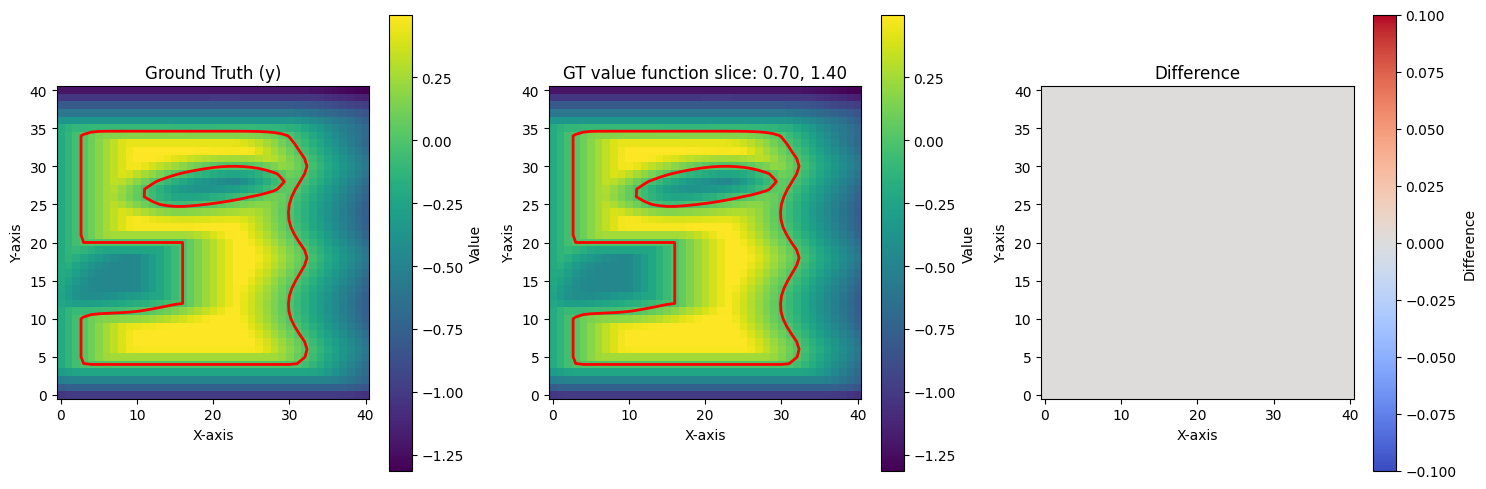

In [8]:
# Calculate the difference
y_gt = data['y'][0].cpu().detach().numpy() #y[0, 0].cpu().detach().numpy()

y_gt_difference = y_gt - gt_value_function[0, :, :, :, :][:, :, xvel_slice_sampletuple, yvel_slice_sampletuple].cpu().detach().numpy()
print("max difference: ", np.max(np.abs(y_gt_difference)))
# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot y
axes[0].imshow(y_gt, cmap='viridis', origin='lower')
axes[0].contour(y_gt, levels=[0], colors="red", linewidths=2)
axes[0].set_title("Ground Truth (y)")
axes[0].set_xlabel("X-axis")
axes[0].set_ylabel("Y-axis")
cbar = fig.colorbar(axes[0].images[0], ax=axes[0])
cbar.set_label("Value")

# Plot y_pred
axes[1].imshow(gt_value_function[0, :, :, :, :][:, :, xvel_slice_sampletuple, yvel_slice_sampletuple].cpu().detach().numpy(), cmap='viridis', origin='lower')
axes[1].contour(gt_value_function[0, :, :, :, :][:, :, xvel_slice_sampletuple, yvel_slice_sampletuple].cpu().detach().numpy(), levels=[0], colors="red", linewidths=2)
axes[1].set_title(f"GT value function slice: {xvels[xvel_slice_sampletuple]:.2f}, {yvels[yvel_slice_sampletuple]:.2f}")
axes[1].set_xlabel("X-axis")
axes[1].set_ylabel("Y-axis")
cbar = fig.colorbar(axes[1].images[0], ax=axes[1])
cbar.set_label("Value")

# Plot the difference
axes[2].imshow(y_gt_difference, cmap='coolwarm', origin='lower')
axes[2].set_title("Difference")
axes[2].set_xlabel("X-axis")
axes[2].set_ylabel("Y-axis")
cbar = fig.colorbar(axes[2].images[0], ax=axes[2])
cbar.set_label("Difference")

plt.tight_layout()
plt.show()

In [9]:
print("data y shape: ", data['y'].shape)
print("y shape: ", y.shape)


data y shape:  torch.Size([1, 41, 41])
y shape:  torch.Size([1, 1, 41, 41])


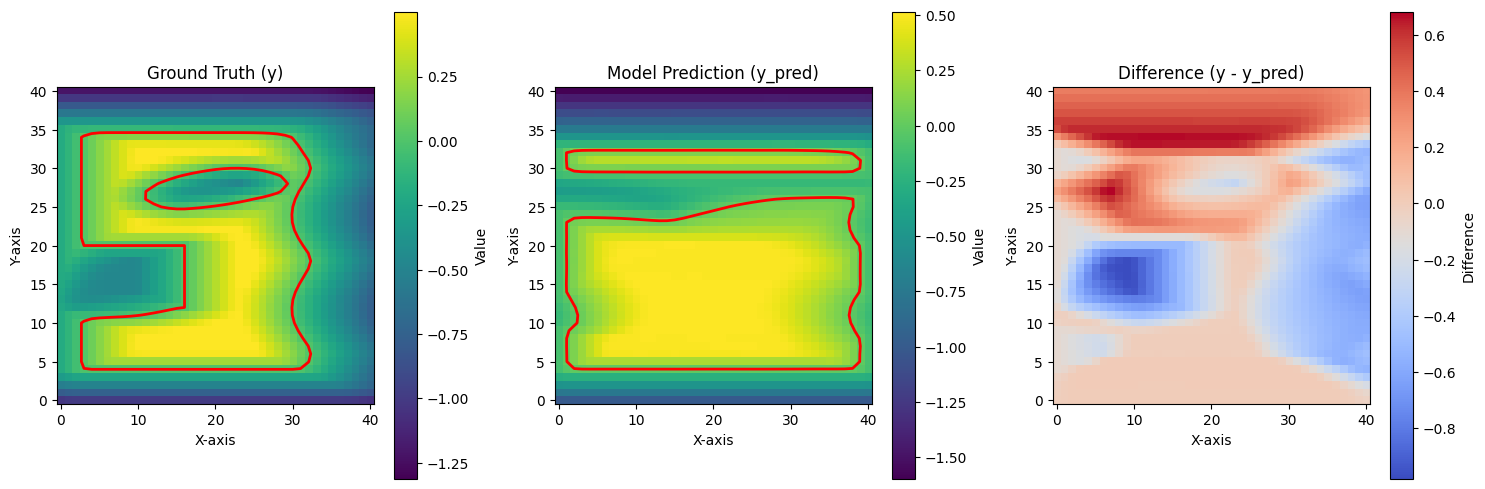

In [10]:
# Calculate the difference
difference = y[0, 0].cpu().detach().numpy() - y_pred[0, 0].cpu().detach().numpy()

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot y
axes[0].imshow(y[0, 0].cpu().detach().numpy(), cmap='viridis', origin='lower')
axes[0].contour(y[0, 0].cpu().detach().numpy(), levels=[0], colors="red", linewidths=2)
axes[0].set_title("Ground Truth (y)")
axes[0].set_xlabel("X-axis")
axes[0].set_ylabel("Y-axis")
cbar = fig.colorbar(axes[0].images[0], ax=axes[0])
cbar.set_label("Value")

# Plot y_pred
axes[1].imshow(y_pred[0, 0].cpu().detach().numpy(), cmap='viridis', origin='lower')
axes[1].contour(y_pred[0, 0].cpu().detach().numpy(), levels=[0], colors="red", linewidths=2)
axes[1].set_title("Model Prediction (y_pred)")
axes[1].set_xlabel("X-axis")
axes[1].set_ylabel("Y-axis")
cbar = fig.colorbar(axes[1].images[0], ax=axes[1])
cbar.set_label("Value")

# Plot the difference
axes[2].imshow(difference, cmap='coolwarm', origin='lower')
axes[2].set_title("Difference (y - y_pred)")
axes[2].set_xlabel("X-axis")
axes[2].set_ylabel("Y-axis")
cbar = fig.colorbar(axes[2].images[0], ax=axes[2])
cbar.set_label("Difference")

plt.tight_layout()
plt.show()

(1, 3)
torch.Size([1, 41, 41])
Input data shape:  torch.Size([50, 1, 41, 41])
Output data shape:  torch.Size([50, 1, 41, 41, 41, 41])
All input data shape:  torch.Size([100, 41, 41])
All output data shape:  torch.Size([100, 41, 41, 41, 41])
All TRAIN input data shape:  torch.Size([50, 41, 41])


/tmp/ipykernel_940300/2883435030.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  print("Input data shape: ", torch.tensor(eval_dataset.input_data).shape)
/tmp/ipykernel_940300/2883435030.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  print("Output data shape: ", torch.tensor(eval_dataset.output_data).shape)
/tmp/ipykernel_940300/2883435030.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  print("All input data shape: ", torch.tensor(dataset.all_input_data).shape)
/tmp/ipykernel_940300/2883435030.py:9: UserWarning: To copy const

All TRAIN output data shape:  torch.Size([50, 41, 41, 41, 41])
All TEST input data shape:  torch.Size([50, 41, 41])
All TEST output data shape:  torch.Size([50, 41, 41, 41, 41])


/tmp/ipykernel_940300/2883435030.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  print("All TEST input data shape: ", torch.tensor(dataset.test_input_data).shape)
/tmp/ipykernel_940300/2883435030.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  print("All TEST output data shape: ", torch.tensor(dataset.test_output_data).shape)


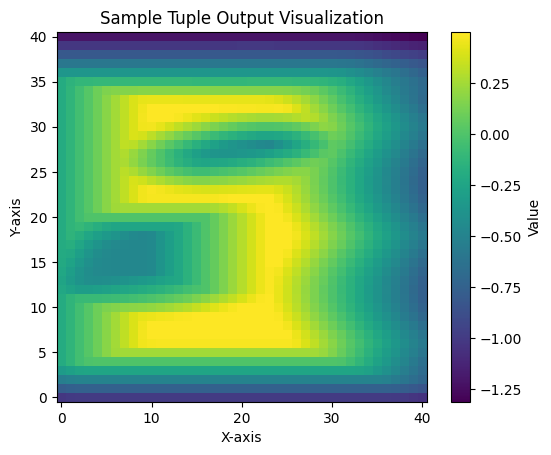

In [11]:
# Test the get item sampling function 
sample_tuple_input = np.array(gt_sample_tuple)
print(sample_tuple_input.shape )
thing = eval_dataset.sample_tuple_list_to_outputs(sample_tuple_input)
print(thing.shape)
print("Input data shape: ", torch.tensor(eval_dataset.input_data).shape)
print("Output data shape: ", torch.tensor(eval_dataset.output_data).shape)
print("All input data shape: ", torch.tensor(dataset.all_input_data).shape)
print("All output data shape: ", torch.tensor(dataset.all_output_data).shape)
print("All TRAIN input data shape: ", torch.tensor(dataset.train_input_data).shape)
print("All TRAIN output data shape: ", torch.tensor(dataset.train_output_data).shape)
print("All TEST input data shape: ", torch.tensor(dataset.test_input_data).shape)
print("All TEST output data shape: ", torch.tensor(dataset.test_output_data).shape)


plt.figure()
plt.imshow(thing[0, :, :], cmap='viridis', origin='lower')
plt.colorbar(label='Value')
plt.title("Sample Tuple Output Visualization")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

torch.Size([1, 3, 41, 41])
torch.Size([1, 41, 41])
tensor(894.7822, device='cuda:0')


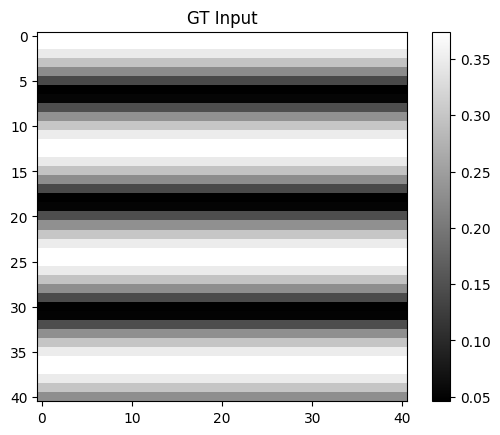

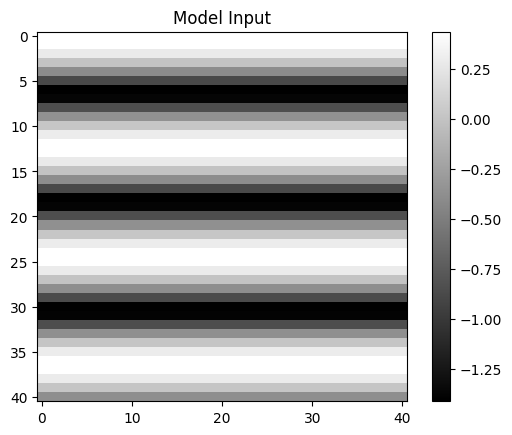

In [12]:
print(x.shape)
print(gt_input.shape)

diff = gt_input[0].to(device) - x[0, 0, :, :].to(device)
print(torch.sum(torch.abs(diff)))

plt.figure()
plt.title("GT Input")
plt.imshow(gt_input[0, :, :].cpu().detach().numpy(), cmap='gray')
plt.colorbar()
plt.show()

plt.figure()
plt.title("Model Input")
plt.imshow(x[0, 0, :, :].cpu().detach().numpy(), cmap='gray')
plt.colorbar()
plt.show()

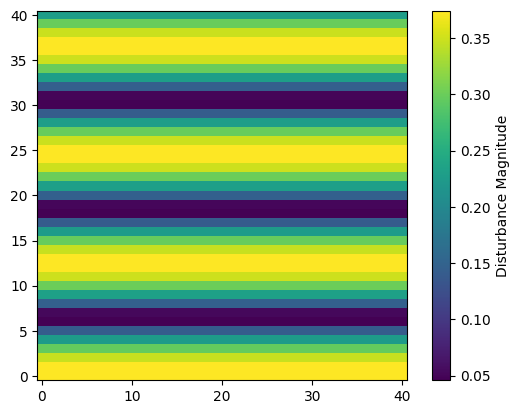

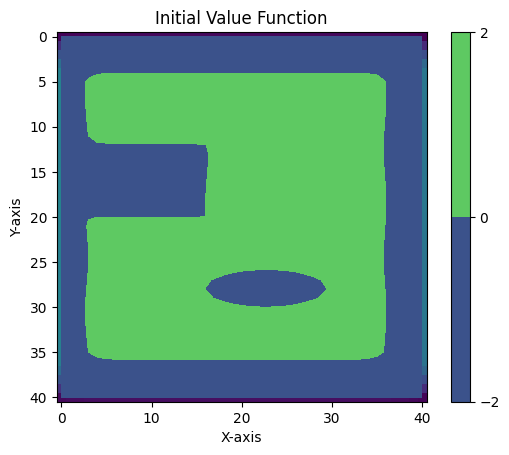

In [13]:
# Visualize environment: l(x) and disturbance map 
# Create disturbance map input
disturbance_input_tensor = gt_input[0, :, :]

# Create l(x) value function for visualization
xvel_slice = 41//2
yvel_slice = 41//2
init_value_function = gt_value_function[0, :, :, :, :][:, :, xvel_slice, yvel_slice]

# Visualize disturbance map 
plt.figure()
plt.imshow(disturbance_input_tensor, cmap='viridis', origin='lower')
plt.colorbar(label='Disturbance Magnitude')

# Visualize l(x)
plt.figure()
plt.imshow(np.array(init_value_function))
plt.contourf(np.array(init_value_function), levels=0, cmap='viridis')
plt.colorbar()
plt.title("Initial Value Function")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

In [14]:
# Model Prediction
from fly_around import get_gridvalue_function_from_model
grid_value_function, channel_dim, flattened_tensor_dataset  = get_gridvalue_function_from_model(
    disturbance_input=disturbance_input_tensor, 
    grid_states=np.array(eval_dataset.grid_states), 
    model=model, 
    data_processor=data_processor, 
    device=device)


/home/jingpei/Documents/arclab/neuraloperator/safe_neural_operators/fly_around.py:83: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  disturbance_input_tensor = torch.tensor(disturbance_input)


xvel slice:  35 yvel slice:  35
xvel:  1.5 yvel:  1.5

GT Value Function slice shape:  torch.Size([41, 41])


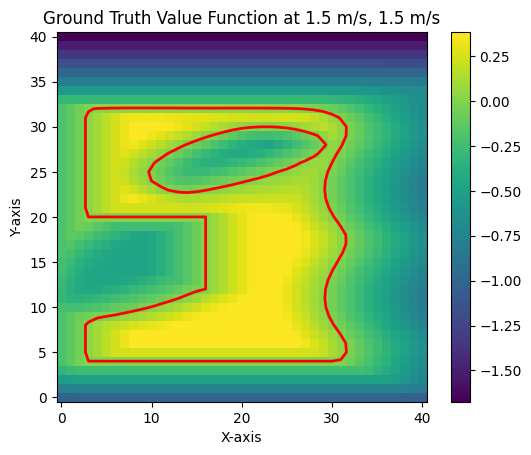

Model Value Function shape:  torch.Size([41, 41])


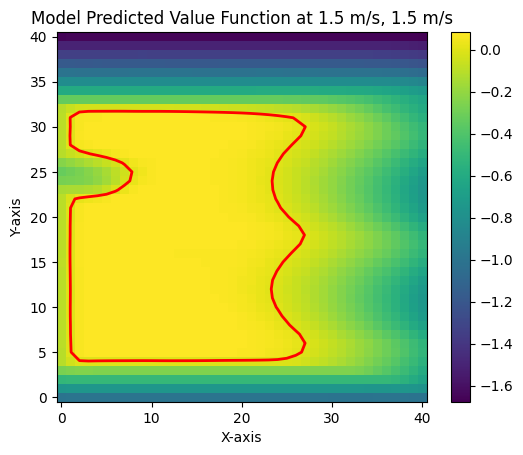

In [15]:

# Visualize the same slice from gt and model prediction
xvel_slice = 41//2
yvel_slice = 41//2

xvel_slice = 35 
yvel_slice = 35 
xvels = eval_dataset.grid_states[0, 0, :, 0, 2]
yvels = eval_dataset.grid_states[0, 0, 0, :, 3]

xvel = xvels[xvel_slice]
yvel = yvels[yvel_slice]

# print("All xvels: ", xvels)
# print("All yvels: ", yvels)
# print()

print("xvel slice: ", xvel_slice, "yvel slice: ", yvel_slice)
print("xvel: ", xvel, "yvel: ", yvel)
print()

# Plot Ground Truth Value Function 
time_slice = -1
gt_value_function_slice = gt_value_function[time_slice, :, :, :, :]
gt_value_function_slice = gt_value_function_slice[:, :, xvel_slice, yvel_slice]

print("GT Value Function slice shape: ", gt_value_function_slice.shape)

plt.figure()
plt.imshow(gt_value_function_slice, cmap='viridis', origin='lower')
plt.colorbar()
plt.contour(gt_value_function_slice, levels=[0], colors='red', linewidths=2)
plt.title(f"Ground Truth Value Function at {xvel} m/s, {yvel} m/s")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

# Plot Model Prediction Value Function
model_value_function_slice = grid_value_function[:, :, xvel_slice, yvel_slice]

print("Model Value Function shape: ", model_value_function_slice.shape)

plt.figure()
plt.imshow(model_value_function_slice, cmap='viridis', origin='lower')
plt.colorbar()
plt.contour(model_value_function_slice, levels=[0], colors='red', linewidths=2)
plt.title(f"Model Predicted Value Function at {xvel} m/s, {yvel} m/s")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

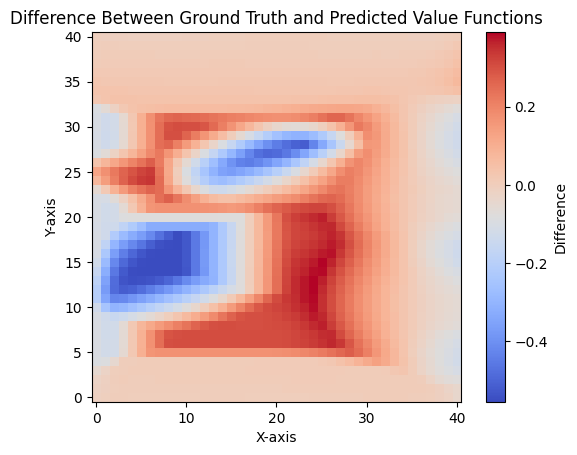

In [16]:
# Calculate the difference
difference = gt_value_function_slice - model_value_function_slice.numpy()

# Plot the difference
plt.figure()
plt.imshow(difference, cmap='coolwarm', origin='lower')
plt.colorbar(label='Difference')
plt.title("Difference Between Ground Truth and Predicted Value Functions")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()